# MAG — Grafi con attributi di nodo

Notebook basato sul modello **MAG (Multiplicative Attribute Graph)** di Kim & Leskovec (UAI 2011).

Pipeline:
1. **Generazione** di grafi sintetici con un attributo binario per nodo, campionato da `Bernoulli(μ)`.
2. La probabilità di ogni arco `(i,j)` è `Θ[F_i, F_j]` — la matrice di affinità `Θ` determina la struttura.
3. **Embedding** EDRep di ogni grafo con i nodi partizionati per attributo.
4. **Distanza W2** tra coppie di grafi usando `block_dists` + `graph_distance` da `functions.py`.
5. **Visualizzazione** della matrice di distanze e dei contributi per blocco.

Tre regimi strutturali (come Figura 5 del paper):
- **Homophily**: nodi con lo stesso attributo si connettono più spesso
- **Heterophily**: nodi con attributo diverso si connettono più spesso
- **Core-Periphery**: attributo 0 = core denso, attributo 1 = periferia sparsa

In [60]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import itertools
import sys
import os

from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import normalized_mutual_info_score as NMI
from sklearn.metrics import confusion_matrix

# Project root is two levels up from notebooks/experiments/
sys.path.insert(0, os.path.abspath('../..'))

from functions import (
    node_embedding,
    block_dists,
    graph_distance,
    w2_distance_classes,
    plot_wasserstein_heatmap,
)

## 1. Generatore MAG (L = 1 attributo binario)

In [61]:
def generate_mag_graph(n, mu, Theta, seed=None):
    """
    Genera un grafo MAG con un singolo attributo binario per nodo.

    Ogni nodo i riceve un attributo F_i ~ Bernoulli(mu).
    La probabilità dell'arco (i,j) è Theta[F_i, F_j].

    Parameters
    ----------
    n     : numero di nodi
    mu    : parametro Bernoulli per l'attributo binario
    Theta : matrice di affinità 2x2  (Theta[a,b] = prob arco tra nodi con attr a e b)
    seed  : seed per la riproducibilità

    Returns
    -------
    G : networkx.Graph con attributo di nodo 'attribute' in {0, 1}
    F : np.ndarray di forma (n,) — vettore degli attributi
    """
    rng = np.random.default_rng(seed)
    F = rng.binomial(1, mu, n)

    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        G.nodes[i]['attribute'] = int(F[i])

    # Campionamento vettorizzato degli archi tramite indici triangolari superiori
    i_idx, j_idx = np.triu_indices(n, k=1)
    p_ij = Theta[F[i_idx], F[j_idx]]
    mask = rng.random(len(i_idx)) < p_ij
    G.add_edges_from(zip(i_idx[mask].tolist(), j_idx[mask].tolist()))

    return G, F

## 2. Definizione dei regimi strutturali

In [73]:
n = 1000   # nodi per grafo
mu = 0.5      # classi bilanciate
n_graphs = 5  # grafi per regime

# Matrici di affinità scalate per grafi sparsi (grado medio ≈ 15)
# Corrispondono ai tre casi di Figura 5 in Kim & Leskovec (2011)
settings = {
    'Homophily': np.array([[0.08, 0.01],
                            [0.01, 0.08]]),
    'Heterophily': np.array([[0.01, 0.08],
                              [0.08, 0.01]]),
    'Core-Periphery': np.array([[0.12, 0.05],
                                 [0.05, 0.01]]),
}

print("Regimi strutturali:")
for name, Theta in settings.items():
    avg_p = mu**2 * Theta[0,0] + 2*mu*(1-mu) * Theta[0,1] + (1-mu)**2 * Theta[1,1]
    expected_degree = avg_p * (n - 1)
    print(f"  {name}: grado medio atteso ≈ {expected_degree:.1f}")

Regimi strutturali:
  Homophily: grado medio atteso ≈ 45.0
  Heterophily: grado medio atteso ≈ 45.0
  Core-Periphery: grado medio atteso ≈ 57.4


## 3. Generazione dei grafi

In [74]:
graphs = {}  # nome -> list of (G, F)
for name, Theta in settings.items():
    graphs[name] = [generate_mag_graph(n, mu, Theta, seed=s) for s in range(n_graphs)]
    G0, F0 = graphs[name][0]
    print(f"{name}:")
    print(f"  nodi={G0.number_of_nodes()}, archi={G0.
          number_of_edges()}, "
          f"attr-0: {int((F0==0).sum())}, attr-1: {int((F0==1).sum())}")

Homophily:
  nodi=1000, archi=22323, attr-0: 473, attr-1: 527
Heterophily:
  nodi=1000, archi=22582, attr-0: 473, attr-1: 527
Core-Periphery:
  nodi=1000, archi=27136, attr-0: 473, attr-1: 527


## 4. Visualizzazione — un grafo di esempio per regime

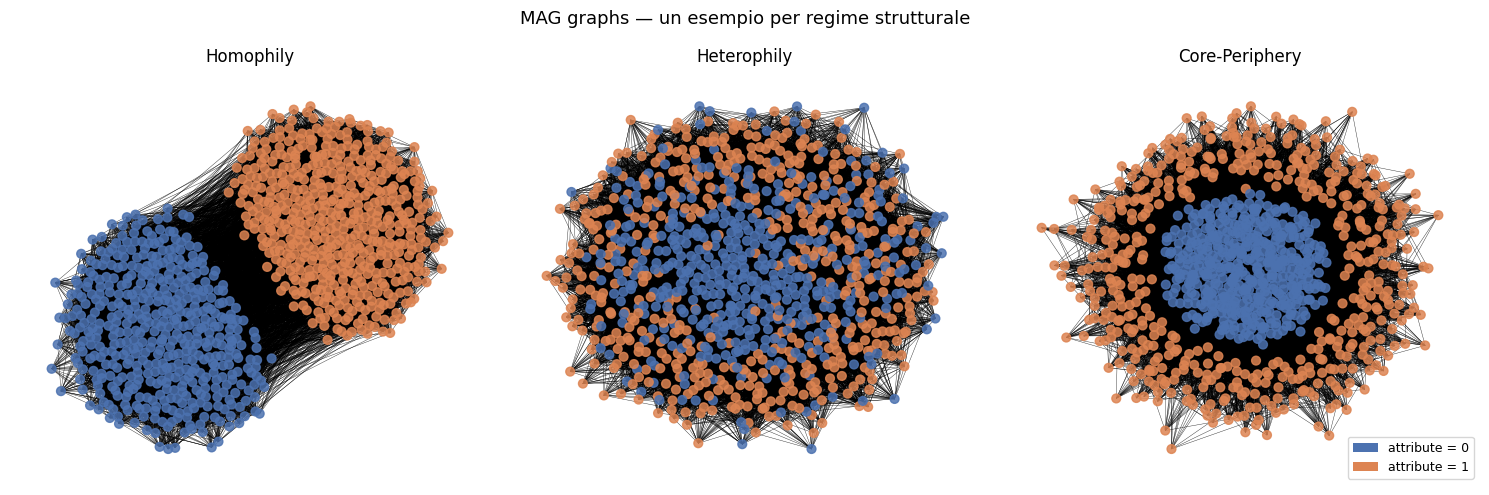

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('MAG graphs — un esempio per regime strutturale', fontsize=13)

color_map = {0: '#4C72B0', 1: '#DD8452'}  # blu=attr0, arancio=attr1

for ax, (name, gs) in zip(axes, graphs.items()):
    G, F = gs[0]
    pos = nx.spring_layout(G, seed=42, k=0.4)
    node_colors = [color_map[int(f)] for f in F]
    nx.draw_networkx(
        G, pos, ax=ax,
        node_color=node_colors,
        node_size=40,
        width=0.3,
        alpha=0.85,
        with_labels=False,
    )
    ax.set_title(name, fontsize=12)
    ax.axis('off')

legend_elements = [
    mpatches.Patch(facecolor='#4C72B0', label='attribute = 0'),
    mpatches.Patch(facecolor='#DD8452', label='attribute = 1'),
]
axes[-1].legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Embedding EDRep e block distributions

Per ogni grafo:
1. Si partizionano i nodi per attributo: `partition = [nodi con attr=0, nodi con attr=1]`
2. `node_embedding(G, partition, dim)` calcola l'embedding EDRep e restituisce la lista di submatrix per classe
3. `block_dists(X_list)` estrae la distribuzione dei prodotti scalari per ogni blocco `(i,j)`

In [76]:
import ot

dim = 32
bd_all = {}        # (setting_name, graph_idx) -> dizionario block_dists
X_lists_all = {}   # (setting_name, graph_idx) -> X_list  (salvato per il confronto sezione 11)

for name, gs in graphs.items():
    for idx, (G, F) in enumerate(gs):
        # Partizione per attributo binario
        partition = [
            np.where(F == 0)[0].tolist(),
            np.where(F == 1)[0].tolist(),
        ]
        # Embedding con nodi partizionati
        X_list = node_embedding(G, partition, dim_embedding=dim, seed=42)
        # Distribuzione per blocco (intra-classe e inter-classe)
        bd_all[(name, idx)] = block_dists(X_list)
        X_lists_all[(name, idx)] = X_list   # tenuto per confronto partizionato vs no
    print(f"{name}: embeddings calcolati")

print(f"\nTotale grafi: {len(bd_all)}")
sample_bd = list(bd_all.values())[0]
print(f"Blocchi per grafo: {list(sample_bd.keys())}")
print("  (0,0) = intra-classe attr=0, (1,1) = intra-classe attr=1, (0,1) = inter-classe")

Homophily: embeddings calcolati
Heterophily: embeddings calcolati
Core-Periphery: embeddings calcolati

Totale grafi: 15
Blocchi per grafo: [(0, 0), (0, 1), (1, 1)]
  (0,0) = intra-classe attr=0, (1,1) = intra-classe attr=1, (0,1) = inter-classe


## 6. Matrice delle distanze pairwise

`graph_distance(bd_a, bd_b)` calcola la norma L2 delle distanze Wasserstein-1D per ciascun blocco.

In [77]:
keys = list(bd_all.keys())
N = len(keys)
D = np.zeros((N, N))

for i, j in itertools.combinations(range(N), 2):
    d = graph_distance(bd_all[keys[i]], bd_all[keys[j]])
    D[i, j] = D[j, i] = d

labels = [f"{name[:2]}-{idx}" for name, idx in keys]

# Statistiche riassuntive
names = list(settings.keys())
n_g = n_graphs
print("Distanze medie intra-regime:")
for k, nm in enumerate(names):
    block = D[k*n_g:(k+1)*n_g, k*n_g:(k+1)*n_g]
    intra = block[np.triu_indices(n_g, k=1)]
    print(f"  {nm}: {intra.mean():.4f}")

print("\nDistanze medie cross-regime:")
regime_pairs = list(itertools.combinations(range(len(names)), 2))
for ki, kj in regime_pairs:
    cross = D[ki*n_g:(ki+1)*n_g, kj*n_g:(kj+1)*n_g]
    print(f"  {names[ki]} vs {names[kj]}: {cross.mean():.4f}")

Distanze medie intra-regime:
  Homophily: 0.0491
  Heterophily: 0.0016
  Core-Periphery: 0.0019

Distanze medie cross-regime:
  Homophily vs Heterophily: 0.8177
  Homophily vs Core-Periphery: 0.8130
  Heterophily vs Core-Periphery: 0.0072


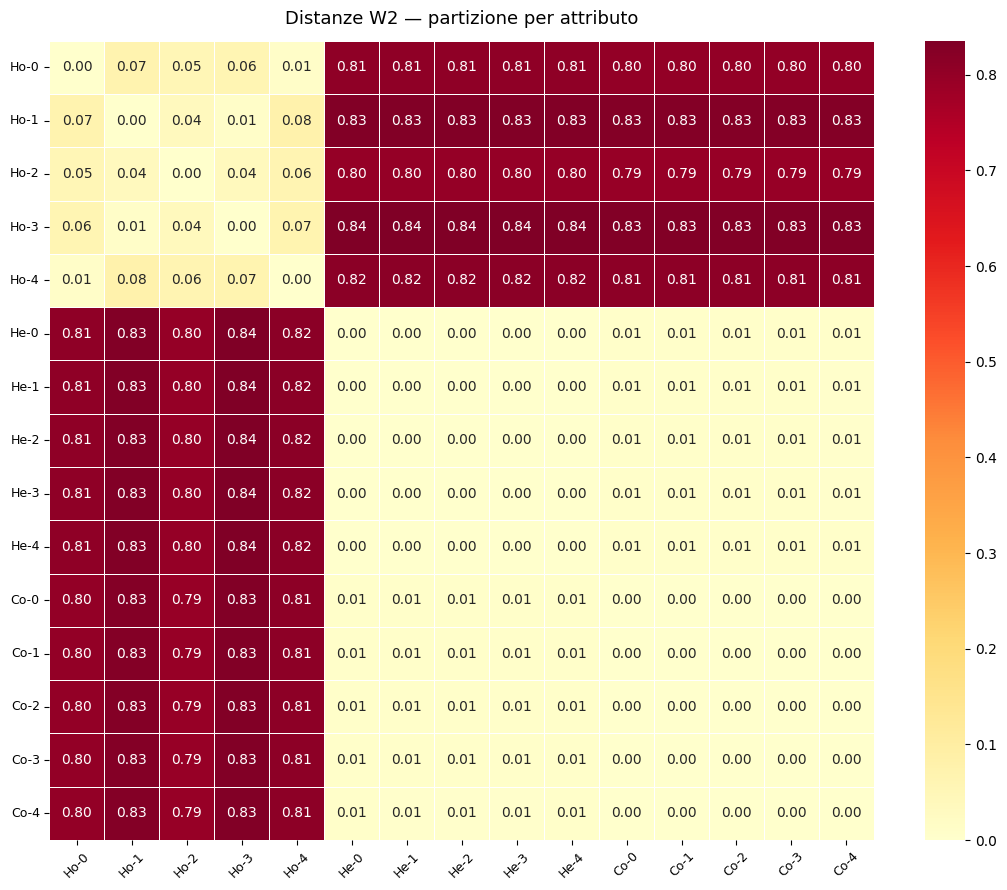

In [78]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    D,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=True,
    fmt='0.2f',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
)


ax.set_title('Distanze W2 — partizione per attributo', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

## 10. Clustering dei grafi e NMI

`ClusterNMF` (da `comparison_models.ipynb`) fattorizza la matrice delle distanze `D` con **NMF**
e raggruppa con **K-Means**, ripetendo 20 volte per trovare la soluzione ottimale.

Il risultato viene confrontato con le etichette vere dei regimi tramite
`normalized_mutual_info_score` (NMI), come in `comparison_models.ipynb`.

### 10a. NMI globale e confusion matrix

In [79]:
def NMF_kmeans(M, k):
    """Fattorizza M con NMF e raggruppa le componenti con K-Means.
    Identica a NMF_kmeans in comparison_models.ipynb."""
    n, _ = M.shape
    Mt = M + np.eye(n) * np.mean(M[M.nonzero()])
    Mt = Mt / np.mean(Mt)
    Y = NMF(n_components=k, max_iter=2000).fit(Mt).components_
    kmeans = KMeans(n_clusters=k, n_init=10).fit(Y.T)
    return kmeans.labels_, np.abs(kmeans.score(Y.T))


def ClusterNMF(M, k):
    """Ripete NMF_kmeans 20 volte e restituisce la soluzione con score minore.
    Identica a ClusterNMF in comparison_models.ipynb."""
    est_l, score = NMF_kmeans(M, k)
    for _ in range(20):
        est_l_, score_ = NMF_kmeans(M, k)
        if score_ < score:
            score = score_
            est_l = est_l_
    return est_l

NMI globale (3 regimi): 0.6154
Accuracy:               0.6667  (10/15 corretti)
(NMI = 1.0, Acc = 1.0 -> clustering perfetto)


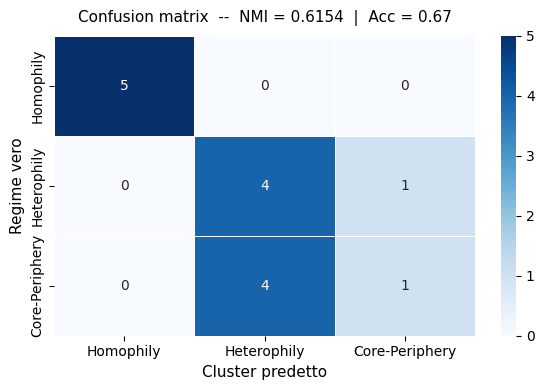

In [80]:
from scipy.optimize import linear_sum_assignment

def align_and_nmi(l_pred, l_true):
    cm_raw = confusion_matrix(l_true, l_pred)
    row_ind, col_ind = linear_sum_assignment(-cm_raw)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    l_aligned = np.array([mapping[p] for p in l_pred])
    acc = (l_aligned == l_true).mean()
    return NMI(l_aligned, l_true), confusion_matrix(l_true, l_aligned), acc

regime_names = list(settings.keys())
k = len(regime_names)

l_true = np.concatenate([[i] * n_graphs for i in range(k)])
l_pred = ClusterNMF(D, k)

nmi_global, cm, acc_global = align_and_nmi(l_pred, l_true)

print(f"NMI globale (3 regimi): {nmi_global:.4f}")
print(f"Accuracy:               {acc_global:.4f}  ({int(acc_global * len(l_true))}/{len(l_true)} corretti)")
print("(NMI = 1.0, Acc = 1.0 -> clustering perfetto)")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=regime_names, yticklabels=regime_names,
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion matrix  --  NMI = {nmi_global:.4f}  |  Acc = {acc_global:.2f}', fontsize=11, pad=10)
ax.set_xlabel('Cluster predetto', fontsize=11)
ax.set_ylabel('Regime vero', fontsize=11)
plt.tight_layout()
plt.show()

### 10b. NMI pairwise tra regimi

Per ogni coppia di regimi, `ClusterNMF` deve separare due classi di `n_graphs` grafi ciascuna.
Si usa il blocco 10×10 della matrice `D` corrispondente ai due regimi.
Un NMI alto indica che la distanza W2 partizionata riesce a distinguere i due regimi strutturali.

NMI pairwise (separabilità tra coppie di regimi):
  Homophily            vs Heterophily         : NMI = 1.0000
  Homophily            vs Core-Periphery      : NMI = 1.0000
  Heterophily          vs Core-Periphery      : NMI = 1.0000


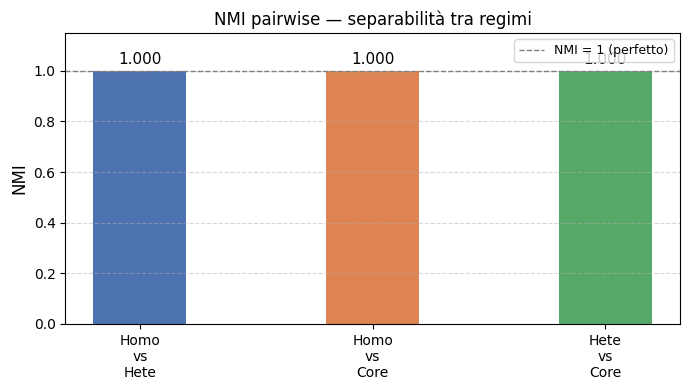

In [81]:
regime_pairs = list(itertools.combinations(range(k), 2))
nmi_pairs = {}

print("NMI pairwise (separabilità tra coppie di regimi):")
for ki, kj in regime_pairs:
    idx = np.concatenate([
        np.arange(ki * n_graphs, (ki + 1) * n_graphs),
        np.arange(kj * n_graphs, (kj + 1) * n_graphs),
    ])
    l_sub = np.concatenate([
        np.zeros(n_graphs, dtype=int),
        np.ones(n_graphs, dtype=int),
    ])
    l_sub_pred = ClusterNMF(D[np.ix_(idx, idx)], k=2)
    nmi_pairs[(ki, kj)] = NMI(l_sub_pred, l_sub)
    print(f"  {regime_names[ki]:20s} vs {regime_names[kj]:20s}: NMI = {nmi_pairs[(ki,kj)]:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
pair_labels = [
    f"{regime_names[ki][:4]}\nvs\n{regime_names[kj][:4]}"
    for ki, kj in regime_pairs
]
nmi_values = [nmi_pairs[p] for p in regime_pairs]
bars = ax.bar(pair_labels, nmi_values,
              color=['#4C72B0', '#DD8452', '#55A868'], width=0.4)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(1.0, ls='--', color='gray', lw=1, label='NMI = 1 (perfetto)')
ax.set_ylabel('NMI', fontsize=12)
ax.set_title('NMI pairwise — separabilità tra regimi', fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 11. Partitioned vs Unpartitioned: la partizione migliora la discriminazione?

**Ipotesi**: la distanza W2 calcolata con i nodi partizionati per attributo
(`block_dists` + `graph_distance`) separa meglio i regimi strutturali rispetto alla
distanza W2 senza nessuna partizione (tutti i nodi in un unico blocco).

**Metrica di confronto**: NMI del clustering `ClusterNMF` sulle rispettive matrici di distanza.

- NMI globale + NMI pairwise: bar chart comparativo

In [82]:
def w2_distance_nopart(X_list_a, X_list_b):
    Xa = [np.concatenate(X_list_a, axis=0)]
    Xb = [np.concatenate(X_list_b, axis=0)]
    return graph_distance(block_dists(Xa), block_dists(Xb))


# Matrice delle distanze senza partizione
D_nopart = np.zeros((N, N))
for i, j in itertools.combinations(range(N), 2):
    d = w2_distance_nopart(X_lists_all[keys[i]], X_lists_all[keys[j]])
    D_nopart[i, j] = D_nopart[j, i] = d


Partitioned   -- NMI = 0.5916  |  Acc = 0.7333  (11/15 corretti)
Unpartitioned -- NMI = 0.6356  |  Acc = 0.8000  (12/15 corretti)


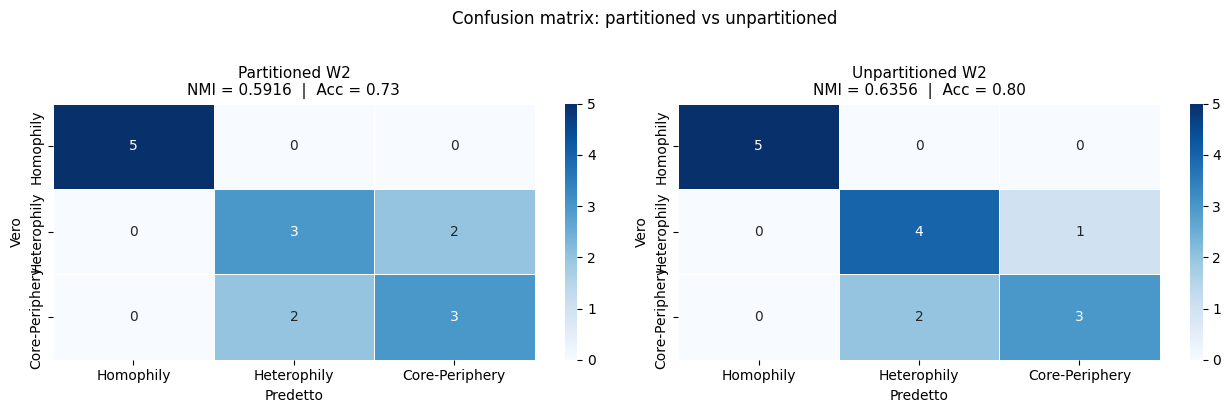


NMI pairwise:
  Homophily            vs Heterophily           partitioned=1.000   unpartitioned=1.000
  Homophily            vs Core-Periphery        partitioned=1.000   unpartitioned=1.000
  Heterophily          vs Core-Periphery        partitioned=1.000   unpartitioned=1.000


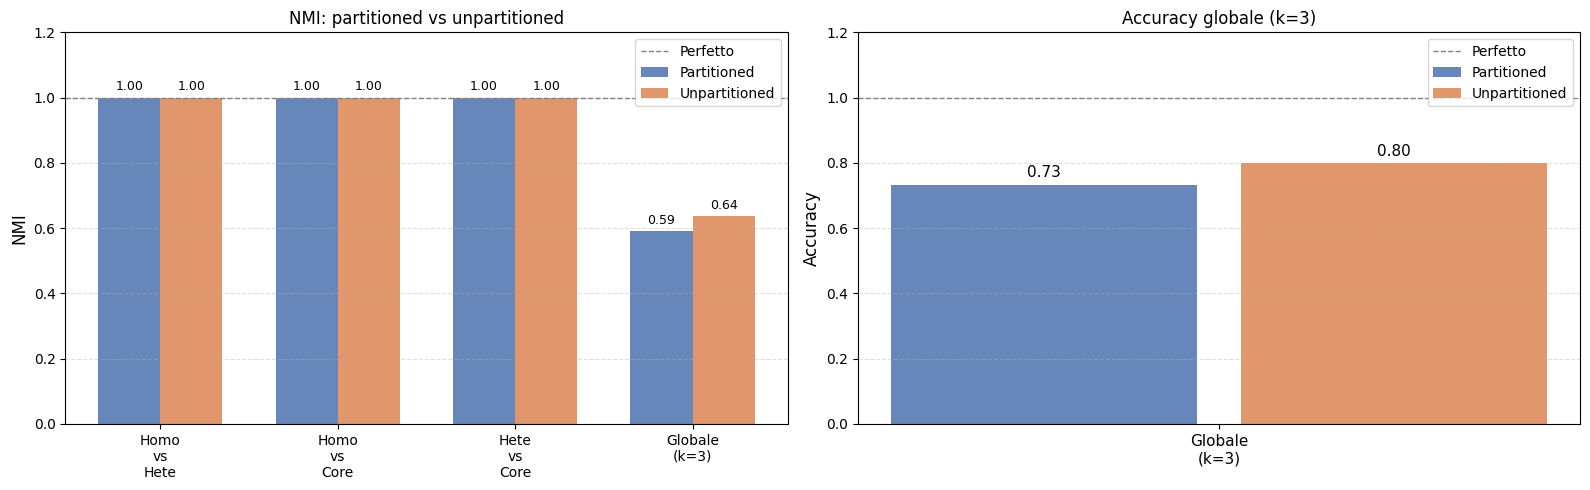

In [83]:
# NMI e Accuracy per entrambi i metodi
l_pred_part   = ClusterNMF(D,        k)
l_pred_nopart = ClusterNMF(D_nopart, k)

nmi_part_global,   cm_part,   acc_part   = align_and_nmi(l_pred_part,   l_true)
nmi_nopart_global, cm_nopart, acc_nopart = align_and_nmi(l_pred_nopart, l_true)

n_tot = len(l_true)
print(f"Partitioned   -- NMI = {nmi_part_global:.4f}  |  Acc = {acc_part:.4f}  ({int(acc_part*n_tot)}/{n_tot} corretti)")
print(f"Unpartitioned -- NMI = {nmi_nopart_global:.4f}  |  Acc = {acc_nopart:.4f}  ({int(acc_nopart*n_tot)}/{n_tot} corretti)")

# Confusion matrix affiancata con NMI e Accuracy nel titolo
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (cm_data, nmi_v, acc_v, title) in zip(axes, [
    (cm_part,   nmi_part_global,   acc_part,   'Partitioned W2'),
    (cm_nopart, nmi_nopart_global, acc_nopart, 'Unpartitioned W2'),
]):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
                xticklabels=regime_names, yticklabels=regime_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f'{title}\nNMI = {nmi_v:.4f}  |  Acc = {acc_v:.2f}', fontsize=11)
    ax.set_xlabel('Predetto', fontsize=10)
    ax.set_ylabel('Vero', fontsize=10)
plt.suptitle('Confusion matrix: partitioned vs unpartitioned', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# NMI pairwise
print("\nNMI pairwise:")
regime_pairs_all = list(itertools.combinations(range(k), 2))
nmi_p_pairs, nmi_np_pairs = [], []

for ki, kj in regime_pairs_all:
    idx = np.concatenate([
        np.arange(ki * n_graphs, (ki + 1) * n_graphs),
        np.arange(kj * n_graphs, (kj + 1) * n_graphs),
    ])
    l_sub = np.concatenate([np.zeros(n_graphs, dtype=int), np.ones(n_graphs, dtype=int)])
    nmi_p  = NMI(ClusterNMF(D[np.ix_(idx, idx)],        k=2), l_sub)
    nmi_np = NMI(ClusterNMF(D_nopart[np.ix_(idx, idx)], k=2), l_sub)
    nmi_p_pairs.append(nmi_p)
    nmi_np_pairs.append(nmi_np)
    print(f"  {regime_names[ki]:20s} vs {regime_names[kj]:20s}  partitioned={nmi_p:.3f}   unpartitioned={nmi_np:.3f}")

# Bar chart NMI + Accuracy affiancati
x = np.arange(len(regime_pairs_all) + 1)
pair_labels_all = (
    [f"{regime_names[ki][:4]}\nvs\n{regime_names[kj][:4]}" for ki, kj in regime_pairs_all]
    + ['Globale\n(k=3)']
)
vals_p_nmi  = nmi_p_pairs  + [nmi_part_global]
vals_np_nmi = nmi_np_pairs + [nmi_nopart_global]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (vals_p, vals_np, ylabel, title) in zip(axes, [
    (vals_p_nmi,  vals_np_nmi,  'NMI',      'NMI: partitioned vs unpartitioned'),
    ([acc_part],  [acc_nopart], 'Accuracy', 'Accuracy globale (k=3)'),
]):
    if ylabel == 'Accuracy':
        bars_p  = ax.bar([0 - 0.2], vals_p,  0.35, label='Partitioned',   color='#4C72B0', alpha=0.85)
        bars_np = ax.bar([0 + 0.2], vals_np, 0.35, label='Unpartitioned', color='#DD8452', alpha=0.85)
        ax.bar_label(bars_p,  fmt='%.2f', padding=3, fontsize=11)
        ax.bar_label(bars_np, fmt='%.2f', padding=3, fontsize=11)
        ax.set_xticks([0])
        ax.set_xticklabels(['Globale\n(k=3)'], fontsize=11)
    else:
        w = 0.35
        bars_p  = ax.bar(x - w/2, vals_p,  w, label='Partitioned',   color='#4C72B0', alpha=0.85)
        bars_np = ax.bar(x + w/2, vals_np, w, label='Unpartitioned', color='#DD8452', alpha=0.85)
        ax.bar_label(bars_p,  fmt='%.2f', padding=3, fontsize=9)
        ax.bar_label(bars_np, fmt='%.2f', padding=3, fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(pair_labels_all, fontsize=10)
    ax.set_ylim(0, 1.2)
    ax.axhline(1.0, ls='--', color='gray', lw=1, label='Perfetto')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()